In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_parquet(r"../Data/sale_and_crime_data/chicago_sales_with_crime.parquet")

In [ ]:
data.shape

(56629, 85)

In [ ]:
data.columns

Index(['pin', 'year', 'township_code', 'neighborhood_code', 'class',
       'sale_date', 'sale_price', 'is_multisale',
       'sale_filter_same_sale_within_365', 'sale_filter_less_than_10k',
       'sale_filter_deed_type', 'year_built', 'building_sqft', 'land_sqft',
       'num_bedrooms', 'num_rooms', 'num_full_baths', 'num_half_baths',
       'num_fireplaces', 'type_of_residence', 'construction_quality',
       'attic_finish', 'garage_size', 'basement_type', 'ext_wall_material',
       'central_heating', 'repair_condition', 'basement_finish',
       'single_v_multi_family', 'central_air', 'pin10', 'zip_code',
       'longitude', 'latitude', 'centroid_x_crs_3435', 'centroid_y_crs_3435',
       'community_area', 'flood_fema_sfha', 'flood_fs_factor',
       'airport_noise_dnl', 'school_elementary_district_name',
       'school_secondary_district_name', 'cmap_walkability_total_score',
       'census_acs5_tract_geoid', 'num_pin_in_half_mile',
       'num_bus_stop_in_half_mile',
       'num

In [ ]:
features_to_exclude = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year']
#excluding pin is clear
#excluding is_multisale since it is always false
#excluding sale_filter_same_sale_within_365 because it is always false
#excluding sale_filter_less_than_10k because it is always false
#excluding single_v_multi_family since we are only looking at single family homes
#excluding zip_code,longitude, and latitude since we want all of the location data to be coming from the community area codes

In [ ]:
cat_features = ["community_area", "type_of_residence", "construction_quality", 
                 "garage_size", "basement_type", "ext_wall_material", "central_heating", "repair_condition",
                "basement_finish", "central_air"
               ]

In [ ]:
data = data.drop(columns = features_to_exclude)

In [ ]:
data = pd.get_dummies(data, columns = cat_features, dtype=int)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
data=data.dropna()
data.shape

(49350, 154)

In [ ]:
y = data["sale_price"]
features = list(data.columns)
features.remove("sale_price")
X = data[features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# --- 1. Split: train / dev / test (e.g. 70/15/15) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
    # 0.1765 * 0.85 ≈ 0.15 → so final split is ~70/15/15
)

# 1. Build a pipeline: scale features, then fit Ridge
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=42))
])

# 2. Fit the model on the training set
pipeline.fit(X_train, y_train)

# 3. Generate predictions
y_train_pred = pipeline.predict(X_train)
y_dev_pred = pipeline.predict(X_dev)

# 4. Compute metrics on test set
test_r2 = r2_score(y_dev, y_dev_pred)
test_mae = mean_absolute_error(y_dev, y_dev_pred)
test_rmse = np.sqrt(mean_squared_error(y_dev, y_dev_pred))

# Compute metrics on train set (for overfitting comparison)
train_r2 = r2_score(y_train, y_train_pred)

# 5. Summarize results
print("R²:    {:.4f}".format(test_r2))
print("MAE:   {:.4f}".format(test_mae))
print("RMSE:  {:.4f}".format(test_rmse))

print("\nTrain R² (for comparison): {:.4f}".format(train_r2))

R²:    0.7727
MAE:   129517.6505
RMSE:  231545.7072

Train R² (for comparison): 0.7909


In [ ]:
# Fit the pipeline on the entire training data
pipeline.fit(X, y)

# Extract the fitted Ridge model and coefficients
ridge_model = pipeline.named_steps["ridge"]
coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Put coefficients into a readable dataframe, sorted by magnitude
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Intercept:", intercept)
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Intercept: 428154.2017629188

Coefficients (sorted by absolute magnitude):
                                  feature   coefficient
                            building_sqft 222074.770588
                         community_area_7 108474.811186
                       basement_type_Full  98974.736166
                       garage_size_2 cars -90571.207021
                       garage_size_0 cars -74925.672479
                       garage_size_1 cars -70252.074529
                    lake_michigan_dist_ft -62426.627023
                        community_area_24  57021.192770
                       basement_type_Slab  56790.814820
                    basement_type_Partial  55987.703193
                         community_area_6  51648.773114
                           num_full_baths  51537.598347
                         community_area_8  51437.522883
                         community_area_5  48464.293400
num_foreclosure_in_half_mile_past_5_years -47339.261677
num_foreclosure_per_1000_pin_

In [ ]:
community_coef_df = coef_df[coef_df["feature"].str.startswith("community_area_")]

print(community_coef_df.to_string(index=False))

          feature   coefficient
 community_area_7 108474.811186
community_area_24  57021.192770
 community_area_6  51648.773114
 community_area_8  51437.522883
 community_area_5  48464.293400
community_area_22  46832.815970
community_area_49 -30588.695029
community_area_44 -28967.190095
community_area_69 -28465.724997
community_area_53 -28389.477663
community_area_48 -27753.168451
community_area_45 -25954.067858
community_area_73 -25287.396733
community_area_46 -24432.920500
community_area_70 -23761.211336
community_area_71 -21207.036900
community_area_72 -20661.855836
community_area_38 -20001.060713
community_area_68 -19248.771614
community_area_50 -19135.349699
community_area_75 -19023.840748
community_area_51 -18395.284245
community_area_67 -18201.474702
 community_area_4  17569.680325
community_area_28  16824.247526
community_area_47 -16656.413041
community_area_25  16083.931392
community_area_42 -13984.910382
community_area_66 -13954.335962
community_area_61 -13534.929305
communit

In [ ]:
import geopandas as gpd

#Use the Root Dataset ID (igwz-8jzy) via the standard SODA API
url_geojson = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"

chicago_map = gpd.read_file(url_geojson)

print("Columns found:", chicago_map.columns.tolist())

#Extract the community area integer
if 'area_numbe' in chicago_map.columns:
    chicago_map['community_area'] = chicago_map['area_numbe'].astype(int)
elif 'area_num_1' in chicago_map.columns:
    chicago_map['community_area'] = chicago_map['area_num_1'].astype(int)
else:
    print("Warning: Could not find the area number column.")

#Verify it worked
print(chicago_map[['community', 'community_area', 'geometry']].head())

Columns found: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len', 'geometry']
        community  community_area  \
0     ROGERS PARK               1   
1      WEST RIDGE               2   
2          UPTOWN               3   
3  LINCOLN SQUARE               4   
4    NORTH CENTER               5   

                                            geometry  
0  MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...  
1  MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...  
2  MULTIPOLYGON (((-87.64102 41.9548, -87.644 41....  
3  MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41...  
4  MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ...  


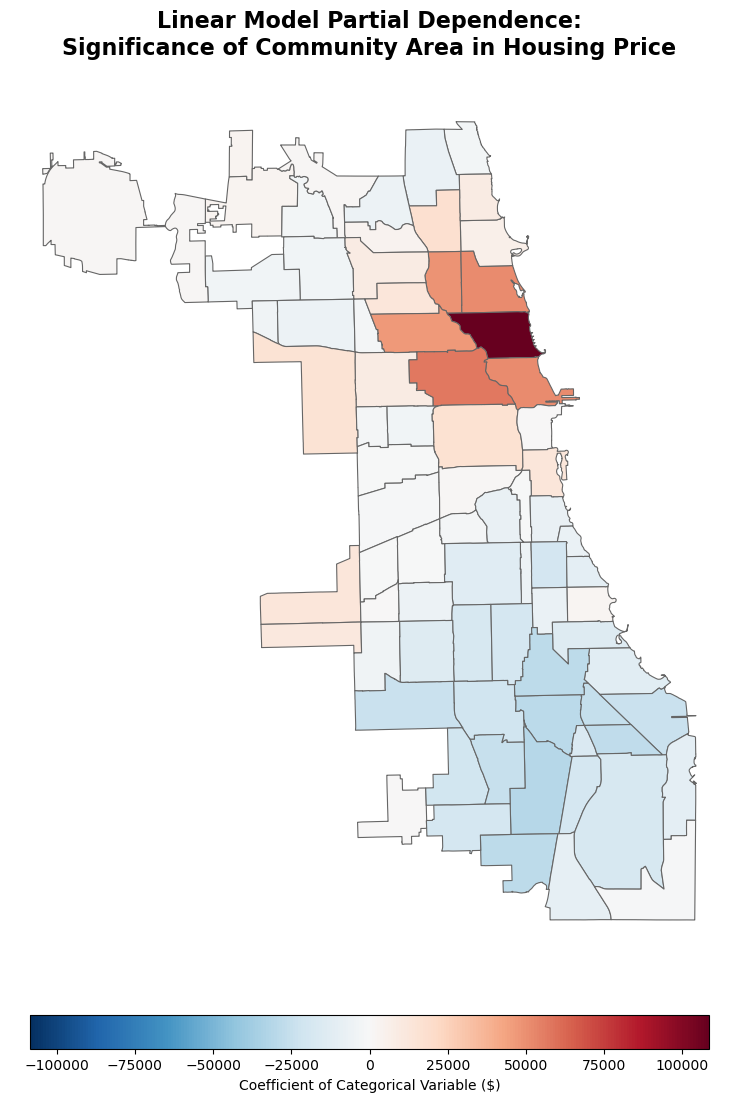

In [ ]:
import matplotlib.pyplot as plt

#Clean the Coefficient DataFrame
coef_df = community_coef_df.copy()

#Extract the integer from the string
coef_df['community_area'] = coef_df['feature'].str.extract(r'(\d+)').astype(int)
coef_series = coef_df.set_index('community_area')['coefficient']

#Map the Data to the Spatial DataFrame
chicago_map['coefficient'] = chicago_map['community_area'].map(coef_series)

chicago_map['coefficient'] = chicago_map['coefficient'].fillna(0)

#Plot the Coefficient Map
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

#Find the maximum absolute value to center the colorbar around 0
max_abs_val = max(chicago_map['coefficient'].abs().max(), 0.0001)

chicago_map.plot(
    column='coefficient', 
    cmap='RdBu_r',             # Red-Blue diverging scale (Red=Negative, Blue=Positive)
    vmin=-max_abs_val,         # Centers 0 directly in the middle of the colorbar
    vmax=max_abs_val, 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.4', 
    legend=True,
    legend_kwds={
        'label': "Coefficient of Categorical Variable ($)", 
        'orientation': "horizontal", 
        'pad': 0.05, 
        'shrink': 0.7
    }
)

#Visual Formatting
ax.set_title("Linear Model Partial Dependence:\nSignificance of Community Area in Housing Price", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()